In [1]:
%run import_libs.py

In [2]:
def cohenD(group1,group2):
    # Calculate means
    mean1 = np.mean(group1)
    mean2 = np.mean(group2)

    # Calculate standard deviations
    std1 = np.std(group1, ddof=1)  # Sample standard deviation
    std2 = np.std(group2, ddof=1)

    # Calculate sample sizes
    n1 = len(group1)
    n2 = len(group2)

    # Calculate pooled standard deviation
    pooledstd = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))

    # Calculate Cohen's d
    cohend = (mean1 - mean2) / pooledstd
    return cohend

In [3]:
def run_cluster_permutation(df, perms = 5000, dataN = 55):

    # initialize an array to store the cluster statistics for each permutation
    fCluster = np.zeros(perms) 

    for n in range(perms):
        print(n)

        # shuffle condition label
        df['randLabel'] = np.random.permutation(df['trlType'].values)
        pseudoVis = df[df.randLabel == 'visual'].iloc[:, 1:dataN+1]
        pseudoVer = df[df.randLabel == 'verbal'].iloc[:, 1:dataN+1]

        # calcualte the permutated statistic (e.g. F values, t values) and p values
        tp = np.array([stats.ttest_ind(pseudoVis.iloc[:, i], pseudoVer.iloc[:, i],
                                        nan_policy='omit')[:2] for i in range(dataN)])

        statArr = tp[:, 0]
        pArr = tp[:, 1]

        # find the consecutive clusters that exceed p value threshold
        consGroups = consecutive(np.where(pArr < 0.05)[0], stepsize=1, findSame=False)

        # find the cluster with the largest length, then find its corresponding t values, sum it up
        # note: if no cluster is found, this will return 0
        fCluster[n] = np.round(
            statArr[consGroups[np.argmax(np.array([len(t) for t in consGroups]))]].sum(), 3
        )

    return fCluster

In [4]:
winsize = 100
freq = 1000
task = 'retrocue'
loadRaw = False
freqOrMag = 'mag'

In [5]:
precue_T = np.array([0.5,1.5,2.5,3,6]) - 0.5
retrocue_T = np.array([0.5,1.5,2,2.5,3,6]) - 0.5

epoch_windows = {
    'precue':   {'stim': (1500, 2500), 'delay': (3000, 6000)},
    'retrocue': {'stim': (500, 1500),  'delay': (3000, 6000)},
}

# Fig 2E, sacc frequency

In [104]:
path_root = 'Z:/yueying/gazeObject_YueyingDong/results/'

In [105]:
if loadRaw:
    #load saccade and attach trial information to it
    gs = np.load(path_root + "variables/sacc/gazeShift_360to400.npy",allow_pickle=True)
    if freqOrMag == 'freq':
        saccEvent = gs[0]
        saccEvent[:,1:] = np.where(saccEvent[:,1:] != 0, 1, 0)

        saccFreq = pd.DataFrame(saccEvent[:,1:]).astype(int).rolling(window = winsize,min_periods = winsize,axis = 1).sum()*freq/winsize
        saccFreq['TRIALID'] = saccEvent[:,0]
        saccFreq['task'] = task

        psyFull = pd.DataFrame()
        for i in glob.glob(path_root + 'data/psychopy/*.csv'):
            psyFull = pd.concat([psyFull,pd.read_csv(i).iloc[:,:]],axis = 0)
        saccFreq = saccFreq.merge(psyFull[['stimImage','TRIALID','trlType','participant']])
else:
    saccFreq = pd.read_csv(path_root +'data/saccFreq/saccFreq.csv').iloc[:,1:]


In [106]:
#get the average sacc frequency per subject, then get the subject averaged sacc frequency

meanSaccSubj = saccFreq.groupby(['task','participant']).mean(numeric_only=True)
meanSacc = meanSaccSubj.groupby(['task',]).mean(numeric_only=True)
semSacc = meanSaccSubj.groupby(['task',]).sem(numeric_only=True)

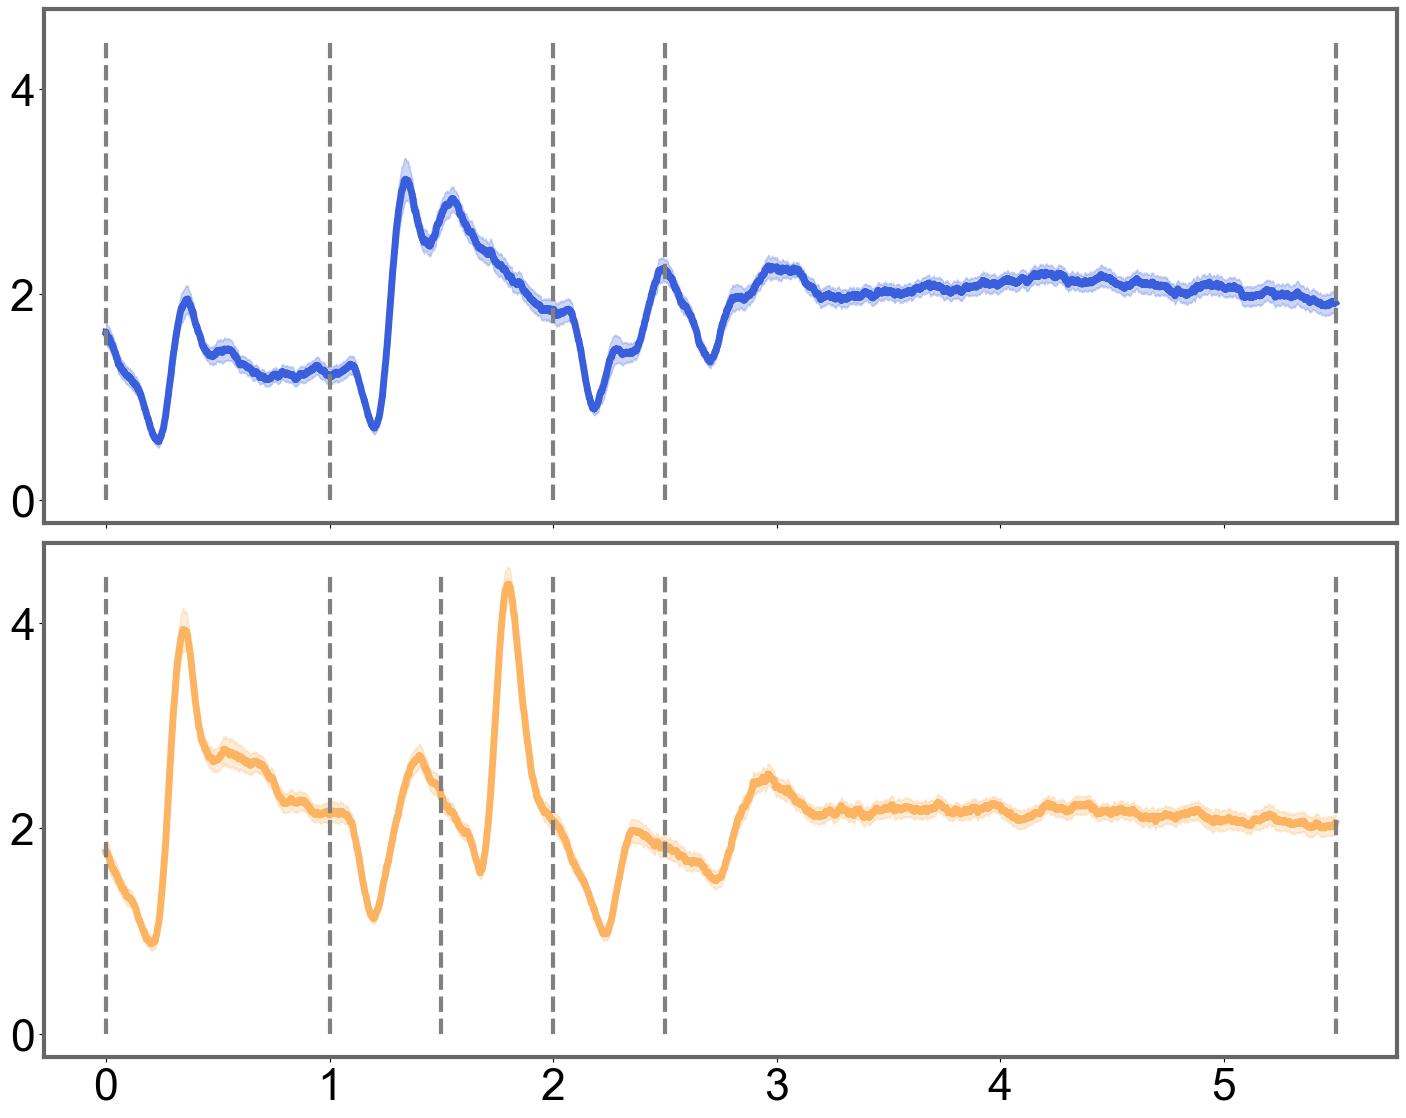

In [68]:
xAxis = np.linspace(0,5.5,5500)
fig,ax = plt.subplots(nrows = 2,figsize = (14,11),sharex=True,sharey = True)
[ax[i%2].plot(xAxis,meanSacc.iloc[i,500:6000],color = ['#395fdc','#fdb462'][i%2],linewidth = 5,
               label = meanSacc.index.get_level_values(0)[i]) for i in range(2)];

[ax[i%2].fill_between(xAxis,meanSacc.iloc[i,500:6000] - semSacc.iloc[i,500:6000],meanSacc.iloc[i,500:6000] + semSacc.iloc[i,500:6000],color = ['#395fdc','#fdb462'][i%2], alpha = 0.25
               ) for i in range(2)];


ax[0].vlines(precue_T,0,4.5,colors = 'grey',linestyles = 'dashed',linewidth = 3)
ax[1].vlines(retrocue_T,0,4.5,colors = 'grey',linestyles = 'dashed',linewidth = 3)

plt.tight_layout()
ax[0].tick_params(axis='y', which='major', labelsize=32)
ax[1].tick_params(axis='y', which='major', labelsize=32)
ax[1].tick_params(axis='x', which='major', labelsize=32)

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(2))


style_spines(ax[0])
style_spines(ax[1])

In [71]:
records = []
for task, windows in epoch_windows.items():
    task_df = meanSaccSubj.loc[task]
    for epoch, (start, end) in windows.items():
        avg = task_df.iloc[:, start:end].mean(axis=1)
        records.append(pd.DataFrame({
            'task': task,
            'participant': avg.index.get_level_values(0),
            'epoch': epoch,
            'avgSaccFreq': avg.values,
        }))

meanSaccSubj_epochAvg = pd.concat(records, ignore_index=True)


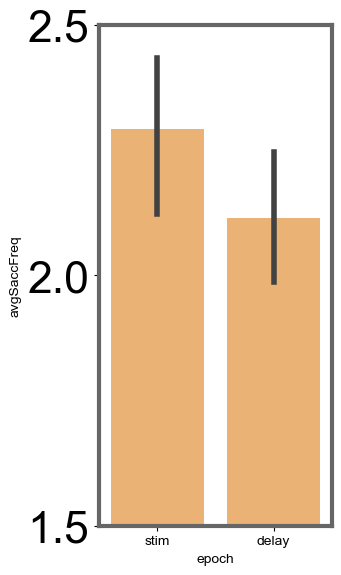

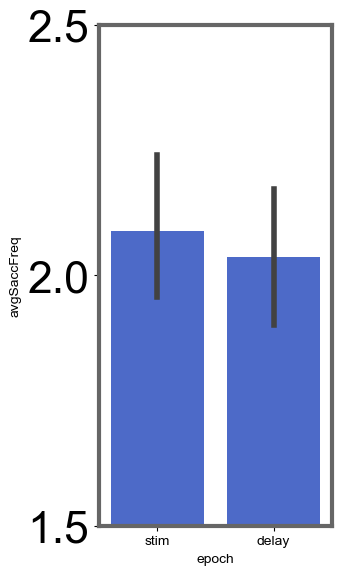

In [73]:
fs(3,6.5)
fig,ax = plt.subplots(ncols=1,sharex=True,sharey=False)

sns.barplot(hue = 'task',x = 'epoch',y = 'avgSaccFreq',linewidth = 10,palette=['#fdb462'],errwidth = 4,
            data = meanSaccSubj_epochAvg[meanSaccSubj_epochAvg.task == 'retrocue'],)

ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.set_ylim(1.5,2.5)
ax.legend().remove()
ax.tick_params(axis='y', which='major', labelsize=32)

style_spines(ax)
plt.show()

fig,ax = plt.subplots(ncols=1,sharex=True,sharey=False)

sns.barplot(hue = 'task',x = 'epoch',y = 'avgSaccFreq',linewidth = 10,palette=['#395fdc'],errwidth = 4,
            data = meanSaccSubj_epochAvg[meanSaccSubj_epochAvg.task == 'precue'],)

ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.set_ylim(1.5,2.5)
ax.tick_params(axis='y', which='major', labelsize=32)
style_spines(ax)
ax.legend().remove()


In [165]:
def compare_stim_delay(df, task, t_test_verbose = True, **kwargs):
    task_df = df[df.task == task]

    anova = pg.rm_anova(data=task_df, effsize='np2',**kwargs)

    stim = task_df.loc[task_df.epoch == 'stim', 'avgSaccFreq']
    delay = task_df.loc[task_df.epoch == 'delay', 'avgSaccFreq']

    t_result = stats.ttest_rel(stim, delay, nan_policy='omit')
    d = round(cohenD(stim, delay), 2)

    if t_test_verbose:
        print(f"t = {t_result.statistic:.2f}, p = {t_result.pvalue:.4f}, d = {d}")

    return anova

anova_precue = compare_stim_delay(meanSaccSubj_epochAvg, 
                                    task = 'precue', 
                                    within = ['epoch'],
                                    subject = 'participant', 
                                    dv = 'avgSaccFreq')
anova_retrocue = compare_stim_delay(meanSaccSubj_epochAvg, 
                                    task = 'retrocue', 
                                    within = ['epoch'],
                                    subject = 'participant', 
                                    dv = 'avgSaccFreq')


t = 0.75, p = 0.4603, d = 0.11
t = 2.56, p = 0.0142, d = 0.38


In [166]:
anova_precue.round(2)

,Source,ddof1,ddof2,F,p-unc,np2,eps
0,epoch,1,40,0.56,0.46,0.01,1.0


In [167]:
anova_retrocue.round(2)

,Source,ddof1,ddof2,F,p-unc,np2,eps
0,epoch,1,40,6.58,0.01,0.14,1.0


# Supp Fig 1, sacc freq

In [350]:
meanSaccSubj = saccFreq.groupby(['task','trlType','participant']).mean(numeric_only=True)
meanSacc = meanSaccSubj.groupby(['task','trlType',]).mean(numeric_only=True)
semSacc = meanSaccSubj.groupby(['task','trlType',]).sem(numeric_only=True)

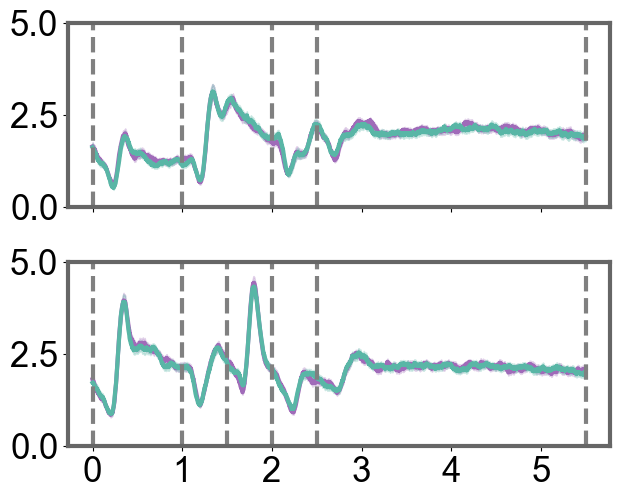

In [351]:
xAxis = np.linspace(0,5.5,5500)
fig,ax = plt.subplots(nrows = 2,figsize = (7,5.5),sharex=True,sharey = True,
                    gridspec_kw={'hspace': 0.3})
[ax[i//2].plot(xAxis,meanSacc.iloc[i,500:6000],color = ['#a06bb9','#59b6a6'][i%2],linewidth = 3,
               label = meanSacc.index.get_level_values(0)[i]+ ', ' + meanSacc.index.get_level_values(1)[i]) for i in range(4)];

[ax[i//2].fill_between(xAxis,meanSacc.iloc[i,500:6000] - semSacc.iloc[i,500:6000],meanSacc.iloc[i,500:6000] + semSacc.iloc[i,500:6000],color = ['#a06bb9','#59b6a6'][i%2], alpha = 0.25
               ) for i in range(4)];

[ax[i].legend().remove() for i in range(2)]

ax[0].vlines(precue_T,0,5,colors = 'grey',linestyles = 'dashed',linewidth = 3)
ax[1].vlines(retrocue_T,0,5,colors = 'grey',linestyles = 'dashed',linewidth = 3)
plt.tight_layout()
ax[0].tick_params(axis='y', which='major', labelsize=25)
ax[1].tick_params(axis='y', which='major', labelsize=25)
ax[1].tick_params(axis='x', which='major', labelsize=25)

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(2.5))

plt.ylim(0,5)

style_spines(ax[0])
style_spines(ax[1])

## permutation

In [377]:
perms = 1000
dataN_ds = 55

In [ ]:
precue_sacc_freq = subset(saccFreq,{'task':['precue']}).set_index(['participant','trlType']).iloc[:,500:6000]
retrocue_sacc_freq = subset(saccFreq,{'task':['retrocue']}).set_index(['participant','trlType']).iloc[:,500:6000]

In [381]:
a = meanSaccSubj.xs('precue').iloc[:,500:6000]
a.columns = range(a.shape[1])
a = a.groupby(a.columns // 100, axis=1).mean()
ds_sacc_precue = a.reset_index(drop=False).drop(columns=['participant'])
fCluster_precue = run_cluster_permutation(ds_sacc_precue, perms, dataN_ds)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

[]


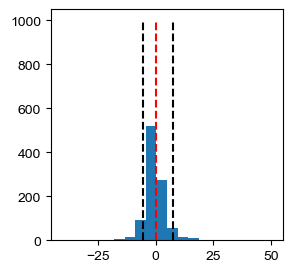

In [ ]:
fs(3,3)
realVis = ds_sacc_precue[ds_sacc_precue.trlType == 'visual'].iloc[:,1:dataN_ds+1]
realVer = ds_sacc_precue[ds_sacc_precue.trlType == 'verbal'].iloc[:,1:dataN_ds+1]

# calcualte the permutated statistic (e.g. F values, t values) and p values
tp = np.array([stats.ttest_ind(realVis.iloc[:,i],realVer.iloc[:,i],
                                nan_policy='omit',) for i in range(dataN_ds)])

statArr = tp[:,0]
pArr = tp[:,1]

# find the clusters that exceed p value threshold
consGroups_precue = consecutive(np.where(pArr < 0.05)[0], stepsize=1,findSame = False)

#get the p value for each cluster
fsum_precue = [statArr[i].sum() for i in consGroups_precue]
pValue_precue = [sum(fCluster_precue > i)/perms for i in fsum_precue]

plt.hist(fCluster_precue,bins = 20)
plt.vlines(np.percentile(fCluster_precue,95),0,perms,linestyles = 'dashed',color ='black')
plt.vlines(np.percentile(fCluster_precue,5),0,perms,linestyles = 'dashed',color ='black')
plt.vlines([fsum_precue],0,perms,linestyles = 'dashed',color ='r')

print([consGroups_precue[i]* 5500/dataN_ds for i in np.where(np.asarray(pValue_precue,dtype=float)>0.95)[0]])

In [386]:
a = meanSaccSubj.xs('retrocue').iloc[:,500:6000]
a.columns = range(a.shape[1])
a = a.groupby(a.columns // 100, axis=1).mean()
ds_sacc_retrocue = a.reset_index(drop=False).drop(columns=['participant'])
fCluster_retrocue = run_cluster_permutation(ds_sacc_retrocue, perms, dataN_ds)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

[]


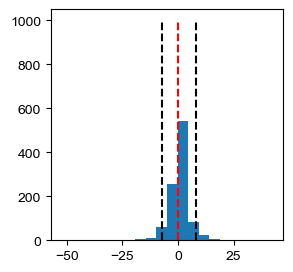

In [ ]:
fs(3,3)
realVis = ds_sacc_retrocue[ds_sacc_retrocue.trlType == 'visual'].iloc[:,1:dataN_ds+1]
realVer = ds_sacc_retrocue[ds_sacc_retrocue.trlType == 'verbal'].iloc[:,1:dataN_ds+1]

# calcualte the permutated statistic (e.g. F values, t values) and p values
tp = np.array([stats.ttest_ind(realVis.iloc[:,i],realVer.iloc[:,i],
                                nan_policy='omit',) for i in range(dataN_ds)])

statArr = tp[:,0]
pArr = tp[:,1]

# find the clusters that exceed p value threshold
consGroups_retrocue = consecutive(np.where(pArr < 0.05)[0], stepsize=1,findSame = False)

#get the p value for each cluster
fsum_retrocue = [statArr[i].sum() for i in consGroups_retrocue]
pValue_retrocue = [sum(fCluster_retrocue > i)/perms for i in fsum_retrocue]

plt.hist(fCluster_retrocue,bins = 20)
plt.vlines(np.percentile(fCluster_retrocue,95),0,perms,linestyles = 'dashed',color ='black')
plt.vlines(np.percentile(fCluster_retrocue,5),0,perms,linestyles = 'dashed',color ='black')
plt.vlines([fsum_retrocue],0,perms,linestyles = 'dashed',color ='r')

print([consGroups_retrocue[i]* 5500/dataN_ds for i in np.where(np.asarray(pValue_retrocue,dtype=float)>0.95)[0]])

# Supp Fig 1, sacc magnitude

In [6]:
psyFull = pd.DataFrame()
for i in glob.glob('Z:/yueying/gazeObject_YueyingDong/results/data/psychopy/*.csv'):
    psyFull = pd.concat([psyFull,pd.read_csv(i).iloc[:,:]],axis = 0)


In [7]:
gs_precue = np.load("Z:/yueying/gazeObject_YueyingDong/results/variables/sacc/gazeShift_311to352.npy",allow_pickle=True)
xMat_precue = gs_precue[0,:,1:]
yMat_precue = gs_precue[1,:,1:]

euc_precue = (xMat_precue** 2 + yMat_precue** 2) 

euc_precue = euc_precue.astype(float)
euc_precue = np.sqrt(euc_precue)

del xMat_precue, yMat_precue

In [8]:
gs_retrocue = np.load("Z:/yueying/gazeObject_YueyingDong/results/variables/sacc/gazeShift_360to400.npy",allow_pickle=True)
xMat_retrocue = gs_retrocue[0,:,1:]
yMat_retrocue = gs_retrocue[1,:,1:]

euc_retrocue = (xMat_retrocue** 2 + yMat_retrocue** 2) 

euc_retrocue = euc_retrocue.astype(float)
euc_retrocue = np.sqrt(euc_retrocue)

del xMat_retrocue, yMat_retrocue

In [9]:
sacc_magnitude_precue = pd.DataFrame(euc_precue)
sacc_magnitude_precue['TRIALID'] = gs_precue[0,:,0]
sacc_magnitude_precue = sacc_magnitude_precue.merge(psyFull[['TRIALID','trlType','participant']])

sacc_magnitude_retrocue = pd.DataFrame(euc_retrocue)
sacc_magnitude_retrocue['TRIALID'] = gs_retrocue[0,:,0]
sacc_magnitude_retrocue = sacc_magnitude_retrocue.merge(psyFull[['TRIALID','trlType','participant']])


In [10]:
sacc_magnitude_precue_subj_mean = sacc_magnitude_precue.groupby(['participant']).mean(numeric_only=True).iloc[:,500:6000]
euc_precue_mean = sacc_magnitude_precue_subj_mean.mean(numeric_only=True).values
euc_precue_sderr = sacc_magnitude_precue_subj_mean.sem(numeric_only=True).values

sacc_magnitude_retrocue_subj_mean = sacc_magnitude_retrocue.groupby(['participant']).mean(numeric_only=True).iloc[:,500:6000]
euc_retrocue_mean = sacc_magnitude_retrocue_subj_mean.mean(numeric_only=True).values
euc_retrocue_sderr = sacc_magnitude_retrocue_subj_mean.sem(numeric_only=True).values



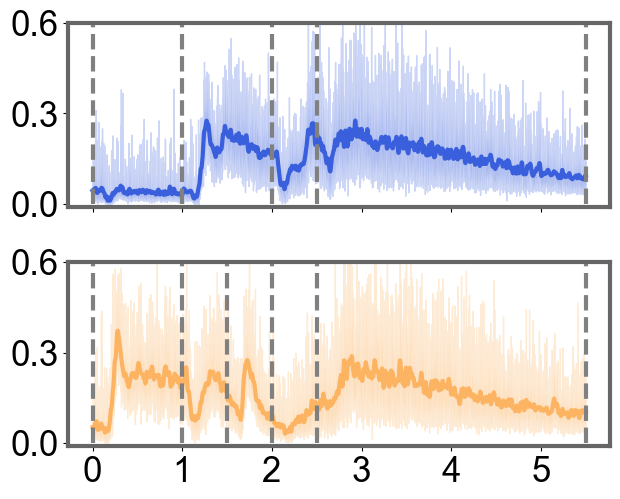

In [11]:
xAxis = np.linspace(0,5.5,5500)
fig,ax = plt.subplots(nrows = 2,figsize = (7,5.5),gridspec_kw={'hspace': 0.3},
                        sharex=True,sharey = True)

ax[0].plot(xAxis, 
    smooth(
        euc_precue_mean,
        window_len = 31
    ),
    color = '#395fdc',
    linewidth = 3,
)
ax[0].fill_between(
    xAxis,
    euc_precue_mean + euc_precue_sderr, 
    euc_precue_mean - euc_precue_sderr, 
    color = '#395fdc',
    alpha = 0.25
) 

ax[1].plot(xAxis, 
    smooth(
        euc_retrocue_mean,
        window_len = 31
    ),
    color = '#fdb462',
    linewidth = 3,
)
ax[1].fill_between(
    xAxis,
    euc_retrocue_mean + euc_retrocue_sderr, 
    euc_retrocue_mean - euc_retrocue_sderr, 
    color = '#fdb462',
    alpha = 0.25,
) 

ax[0].vlines(precue_T,0,0.75,colors = 'grey',linestyles = 'dashed',linewidth = 3)
ax[1].vlines(retrocue_T,0,0.75,colors = 'grey',linestyles = 'dashed',linewidth = 3)

plt.tight_layout()
ax[0].tick_params(axis='y', which='major', labelsize=25)
ax[1].tick_params(axis='y', which='major', labelsize=25)
ax[1].tick_params(axis='x', which='major', labelsize=25)

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.3))
plt.ylim(-0.01,0.6)
style_spines(ax[0])
style_spines(ax[1])



In [12]:
epoch_windows = {
    'precue':   {'stim': (1000, 2000), 'delay': (2500, 5500)},
    'retrocue': {'stim': (0, 1000),  'delay': (2500, 5500)},
}

records = []

for epoch, (start, end) in epoch_windows['precue'].items():
    avg = sacc_magnitude_precue_subj_mean.iloc[:, start:end].mean(axis=1)
    records.append(pd.DataFrame({
        'participant': avg.index.get_level_values(0),
        'task': 'precue',
        'epoch': epoch,
        'avgSaccMag': avg.values,
    }))

for epoch, (start, end) in epoch_windows['retrocue'].items():
    avg = sacc_magnitude_retrocue_subj_mean.iloc[:, start:end].mean(axis=1)
    records.append(pd.DataFrame({
        'participant': avg.index.get_level_values(0),
        'task': 'retrocue',
        'epoch': epoch,
        'avgSaccMag': avg.values,
    }))

sacc_mag_mean = pd.concat(records, ignore_index=True)


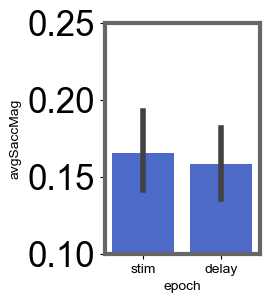

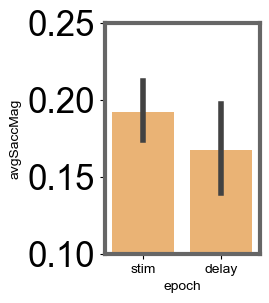

In [13]:
fs(2,3)
fig,ax = plt.subplots(ncols=1,sharex=True,sharey=False)

sns.barplot(hue = 'task',x = 'epoch',y = 'avgSaccMag',linewidth = 10,palette=['#395fdc'],errwidth = 4,
            data = sacc_mag_mean[sacc_mag_mean.task == 'precue'],)

ax.set_ylim(0.1,0.25)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax.tick_params(axis='y', which='major', labelsize=25)
style_spines(ax)
ax.legend().remove()
plt.show()


fig,ax = plt.subplots(ncols=1,sharex=True,sharey=False)

sns.barplot(hue = 'task',x = 'epoch',y = 'avgSaccMag',linewidth = 10,palette=['#fdb462'],errwidth = 4,
            data = sacc_mag_mean[sacc_mag_mean.task == 'retrocue'],)

ax.set_ylim(0.1,0.25)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax.tick_params(axis='y', which='major', labelsize=25)
style_spines(ax)
ax.legend().remove()

In [14]:
def compare_stim_delay(df, task, t_test_verbose = True, **kwargs):
    task_df = df[df.task == task]

    anova = pg.rm_anova(data=task_df, effsize='np2',**kwargs)

    stim = task_df.loc[task_df.epoch == 'stim', 'avgSaccMag']
    delay = task_df.loc[task_df.epoch == 'delay', 'avgSaccMag']

    t_result = stats.ttest_rel(stim, delay, nan_policy='omit')
    d = round(cohenD(stim, delay), 2)

    if t_test_verbose:
        print(f"t = {t_result.statistic:.2f}, p = {t_result.pvalue:.4f}, d = {d}")

    return anova

anova_precue = compare_stim_delay(sacc_mag_mean, 
                                    task = 'precue', 
                                    within = ['epoch'],
                                    subject = 'participant', 
                                    dv = 'avgSaccMag')
anova_retrocue = compare_stim_delay(sacc_mag_mean, 
                                    task = 'retrocue', 
                                    within = ['epoch'],
                                    subject = 'participant', 
                                    dv = 'avgSaccMag')


t = 0.58, p = 0.5672, d = 0.09
t = 1.86, p = 0.0700, d = 0.32


### R2.6, comparing visual and semantic sacc magnitude

In [21]:
sacc_magnitude_precue_subj_mean = sacc_magnitude_precue.groupby(['participant','trlType']).mean(numeric_only=True).iloc[:,100:6000]
sacc_magnitude_retrocue_subj_mean = sacc_magnitude_retrocue.groupby(['participant','trlType']).mean(numeric_only=True).iloc[:,100:6000]

euc_precue_mean = sacc_magnitude_precue_subj_mean.groupby('trlType').mean(numeric_only=True).values
euc_precue_sderr = sacc_magnitude_precue_subj_mean.groupby('trlType').sem(numeric_only=True).values

euc_retrocue_mean = sacc_magnitude_retrocue_subj_mean.groupby('trlType').mean(numeric_only=True).values
euc_retrocue_sderr = sacc_magnitude_retrocue_subj_mean.groupby('trlType').sem(numeric_only=True).values

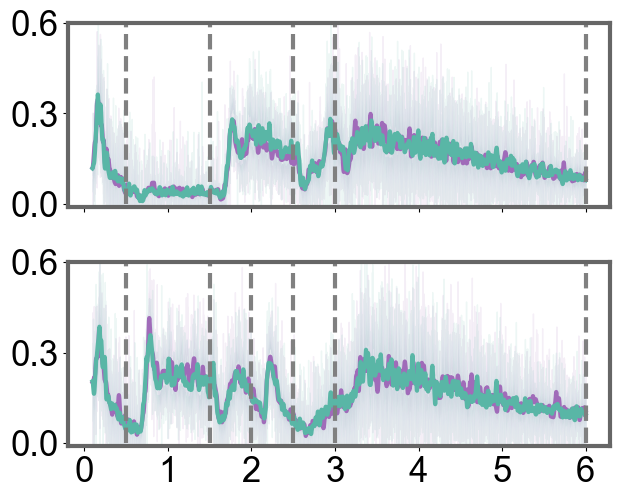

In [22]:
xAxis = np.linspace(0.1,6,5900)
fig,ax = plt.subplots(nrows = 2,figsize = (7,5.5),
                      gridspec_kw={'hspace': 0.3},
                      sharex=True,
                      sharey = True)

def plot_mean_sem(ax, mean, sderr, colors = ('#a06bb9', '#59b6a6'), linewidths = 3,**kwargs):
    
    for i, color in enumerate(colors):
        smooth_mean = smooth(mean[i],**kwargs)
        ax.plot(xAxis, smooth_mean, color = color, linewidth = linewidths)
        ax.fill_between(xAxis, smooth_mean + sderr[i], 
                        smooth_mean - sderr[i], color = color, alpha = 0.1)

plot_mean_sem(ax[0], euc_precue_mean, euc_precue_sderr,window_len = 31)
plot_mean_sem(ax[1], euc_retrocue_mean, euc_retrocue_sderr,window_len = 31)


ax[0].vlines(precue_T+0.5,0,0.6,colors = 'grey',linestyles = 'dashed',linewidth = 3)
ax[1].vlines(retrocue_T+0.5,0,0.6,colors = 'grey',linestyles = 'dashed',linewidth = 3)

plt.tight_layout()
ax[0].tick_params(axis='y', which='major', labelsize=25)
ax[1].tick_params(axis='y', which='major', labelsize=25)
ax[1].tick_params(axis='x', which='major', labelsize=25)

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.3))
plt.ylim(-0.01,0.6)
style_spines(ax[0])
style_spines(ax[1])



#### permutation

In [358]:
perms = 1000
dataN_ds = 55

In [325]:
# subject indifferent
a = sacc_magnitude_precue.drop(columns=['participant','TRIALID']).set_index('trlType').iloc[:,500:6000]
a.columns = range(a.shape[1])
a = a.groupby(a.columns // 100, axis=1).mean()
dsPup_precue = a.reset_index(drop=False).iloc[:,:]
fCluster_precue = run_cluster_permutation(dsPup_precue, perms, dataN_ds)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [362]:
#within subject
a = sacc_magnitude_precue_subj_mean
a.columns = range(a.shape[1])
a = a.groupby(a.columns // 100, axis=1).mean()
dsPup_precue = a.reset_index(drop=False).iloc[:,1:]

fCluster_precue = run_cluster_permutation(dsPup_precue, perms, dataN_ds)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

[]


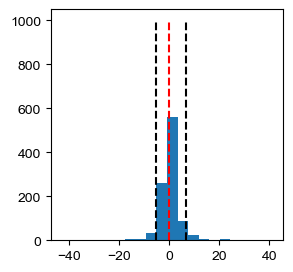

In [ ]:
fs(3,3)
realVis = dsPup_precue[dsPup_precue.trlType == 'visual'].iloc[:,1:dataN_ds+1]
realVer = dsPup_precue[dsPup_precue.trlType == 'verbal'].iloc[:,1:dataN_ds+1]

# calcualte the permutated statistic (e.g. F values, t values) and p values
tp = np.array([stats.ttest_ind(realVis.iloc[:,i],realVer.iloc[:,i],
                                nan_policy='omit',) for i in range(dataN_ds)])

statArr = tp[:,0]
pArr = tp[:,1]

# find the clusters that exceed p value threshold
consGroups_precue = consecutive(np.where(pArr < 0.05)[0], stepsize=1,findSame = False)

#get the p value for each cluster
fsum_precue = [statArr[i].sum() for i in consGroups_precue]
pValue_precue = [sum(fCluster_precue > i)/perms for i in fsum_precue]

plt.hist(fCluster_precue,bins = 20)
plt.vlines(np.percentile(fCluster_precue,95),0,perms,linestyles = 'dashed',color ='black')
plt.vlines(np.percentile(fCluster_precue,5),0,perms,linestyles = 'dashed',color ='black')
plt.vlines([fsum_precue],0,perms,linestyles = 'dashed',color ='r')

print([consGroups_precue[i]* 5500/dataN_ds for i in np.where(np.asarray(pValue_precue,dtype=float)>0.95)[0]])

In [375]:
b = sacc_magnitude_retrocue_subj_mean
b.columns = range(b.shape[1])
b = b.groupby(b.columns // 100, axis=1).mean()
dsPup_retrocue = b.reset_index(drop=False).iloc[:,1:]

fCluster_retrocue = run_cluster_permutation(dsPup_retrocue, perms, dataN_ds)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

[]


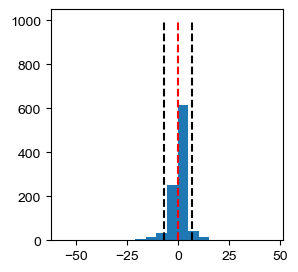

In [ ]:
fs(3,3)
realVis = dsPup_retrocue[dsPup_retrocue.trlType == 'visual'].iloc[:,1:dataN_ds+1]
realVer = dsPup_retrocue[dsPup_retrocue.trlType == 'verbal'].iloc[:,1:dataN_ds+1]

# calcualte the permutated statistic (e.g. F values, t values) and p values
tp = np.array([stats.ttest_ind(realVis.iloc[:,i],realVer.iloc[:,i],
                                nan_policy='omit',) for i in range(dataN_ds)])

statArr = tp[:,0]
pArr = tp[:,1]

# find the clusters that exceed p value threshold
consGroups_retrocue = consecutive(np.where(pArr < 0.05)[0], stepsize=1,findSame = False)

#get the p value for each cluster
fsum_retrocue = [statArr[i].sum() for i in consGroups_retrocue]
pValue_retrocue = [sum(fCluster_retrocue > i)/perms for i in fsum_retrocue]

plt.hist(fCluster_retrocue,bins = 20)
plt.vlines(np.percentile(fCluster_retrocue,95),0,perms,linestyles = 'dashed',color ='black')
plt.vlines(np.percentile(fCluster_retrocue,5),0,perms,linestyles = 'dashed',color ='black')
plt.vlines([fsum_retrocue],0,perms,linestyles = 'dashed',color ='r')

print([consGroups_retrocue[i]* 5500/dataN_ds for i in np.where(np.abs(np.asarray(pValue_retrocue,dtype=float))>0.95)[0]])

# Supp 1, entropy

In [6]:
def get_gaze_heatmap(gaze_clean, tStart, tEnd):
    cols = gaze_clean.iloc[:, 2:].iloc[:, tStart:tEnd]
    gaze_x = gaze_clean[gaze_clean.axis == 'x'].loc[:, cols.columns].values.flatten()
    gaze_y = gaze_clean[gaze_clean.axis == 'y'].loc[:, cols.columns].values.flatten()
    gaze_y_corrected = SCREEN_HEIGHT - gaze_y

    heatmap, _, _ = np.histogram2d(
        gaze_x, gaze_y_corrected,
        bins=BINS,
        range=[imagePosX, imagePosY],
        density=True,
    )
    return gaussian_filter(heatmap, sigma=SIGMA)


def get_gaze_entropy(heatmap, base=2):
    heatmap_norm = heatmap / heatmap.sum()
    xx = heatmap_norm.flatten()
    overall_entropy= entropy(xx[xx>1e-8], base=base)
     
    return overall_entropy

def plot_heatmap(ax, heatmap, title, vmin=None, vmax=None):
    heatmap = heatmap.T
    h, w = heatmap.shape
    ax.imshow(heatmap, cmap='RdBu_r', origin='lower', vmin=vmin, vmax=vmax)
    ax.axis('off')
    ax.set_title(title)

In [7]:
GAZE_PATH = "Z:/yueying/gazeObject_YueyingDong/results/data/gazeClean/cleanGaze_*.csv"
GAZE_EXP_PATH = glob.glob(GAZE_PATH)
PRECUE_GAZE_PATH = GAZE_EXP_PATH[:2]
RETROCUE_GAZE_PATH = GAZE_EXP_PATH[2]

In [13]:

gaze_clean = pd.DataFrame()
for thisFile in PRECUE_GAZE_PATH:
    gaze_clean = pd.concat([gaze_clean,
                            pd.read_csv(thisFile)],
                            axis = 0)
    
epochs = [
    (0,500,'ITI'),
    (500,  1500, 'precue'),
    (1500, 2500, 'stim'),
    (2500, 3000, 'mask'),
    (3000, 6000, 'delay'),
]


In [14]:
imagePosX = [960-270,960+270]
imagePosY = [540-270,540+270]

In [15]:
fs(8.5,5)

In [16]:
BINS = (54,54)
SIGMA = 0.5
SCREEN_HEIGHT = 1080


In [17]:
psyFull = pd.DataFrame()
for i in glob.glob('Z:/yueying/gazeObject_YueyingDong/results/data/psychopy/*.csv'):
    psyFull = pd.concat([psyFull,pd.read_csv(i).iloc[:,:]],axis = 0)
gaze_clean = gaze_clean.merge(psyFull[['TRIALID','trlType','participant']], 
                              how = 'left', on = 'TRIALID')


## precue

In [18]:
gaze_visual = gaze_clean[gaze_clean.trlType == 'visual']
gaze_verbal = gaze_clean[gaze_clean.trlType == 'verbal']

all_participants = gaze_visual.participant.unique()
all_participants_heatmaps_visual = []
all_participants_heatmaps_verbal = []
all_participants_heatmaps = []

rows_visual = []
rows_verbal = []
rows_all = []


for subject in all_participants:
    print(subject)
    
    this_subject = gaze_clean[gaze_clean.participant == subject]
    this_subject_visual = gaze_visual[gaze_visual.participant == subject]
    this_subject_verbal = gaze_verbal[gaze_verbal.participant == subject]

    all_heatmaps_visual = []
    all_heatmaps_verbal = []
    all_heatmaps = []

    for tStart, tEnd, title in epochs:
        #get all heatmaps
        heatmap_visual = get_gaze_heatmap(this_subject_visual, tStart, tEnd)
        heatmap_verbal = get_gaze_heatmap(this_subject_verbal, tStart, tEnd)
        heatmap = get_gaze_heatmap(this_subject, tStart, tEnd)
        
        all_heatmaps_visual.append(heatmap_visual)
        all_heatmaps_verbal.append(heatmap_verbal)
        all_heatmaps.append(heatmap)

        #get entropy
        rows_visual.append({'participant': subject, 'epoch': title,
                                    'overall': get_gaze_entropy(heatmap_visual)})
        rows_verbal.append({'participant': subject, 'epoch': title,
                                    'overall': get_gaze_entropy(heatmap_verbal)})
        rows_all.append({'participant': subject, 'epoch': title,
                         'overall': get_gaze_entropy(heatmap)})

        

    
    all_participants_heatmaps_visual.append(np.array(all_heatmaps_visual))
    all_participants_heatmaps_verbal.append(np.array(all_heatmaps_verbal))
    all_participants_heatmaps.append(np.array(all_heatmaps))

df_visual = pd.DataFrame(rows_visual)
df_verbal = pd.DataFrame(rows_verbal)
df_all = pd.DataFrame(rows_all)

311.0
312.0
313.0
314.0
315.0
316.0
317.0
318.0
319.0
320.0
321.0
322.0
324.0
325.0
326.0
327.0
328.0
329.0
330.0
331.0
332.0
333.0
334.0
335.0
336.0
337.0
338.0
339.0
340.0
341.0
342.0
343.0
344.0
345.0
346.0
347.0
348.0
349.0
350.0
351.0
352.0


In [21]:
heatmaps_avg = np.array(all_participants_heatmaps).mean(axis=0)
heatmaps_visual_avg = np.array(all_participants_heatmaps_visual).mean(axis=0)
heatmaps_verbal_avg = np.array(all_participants_heatmaps_verbal).mean(axis=0)


### agg

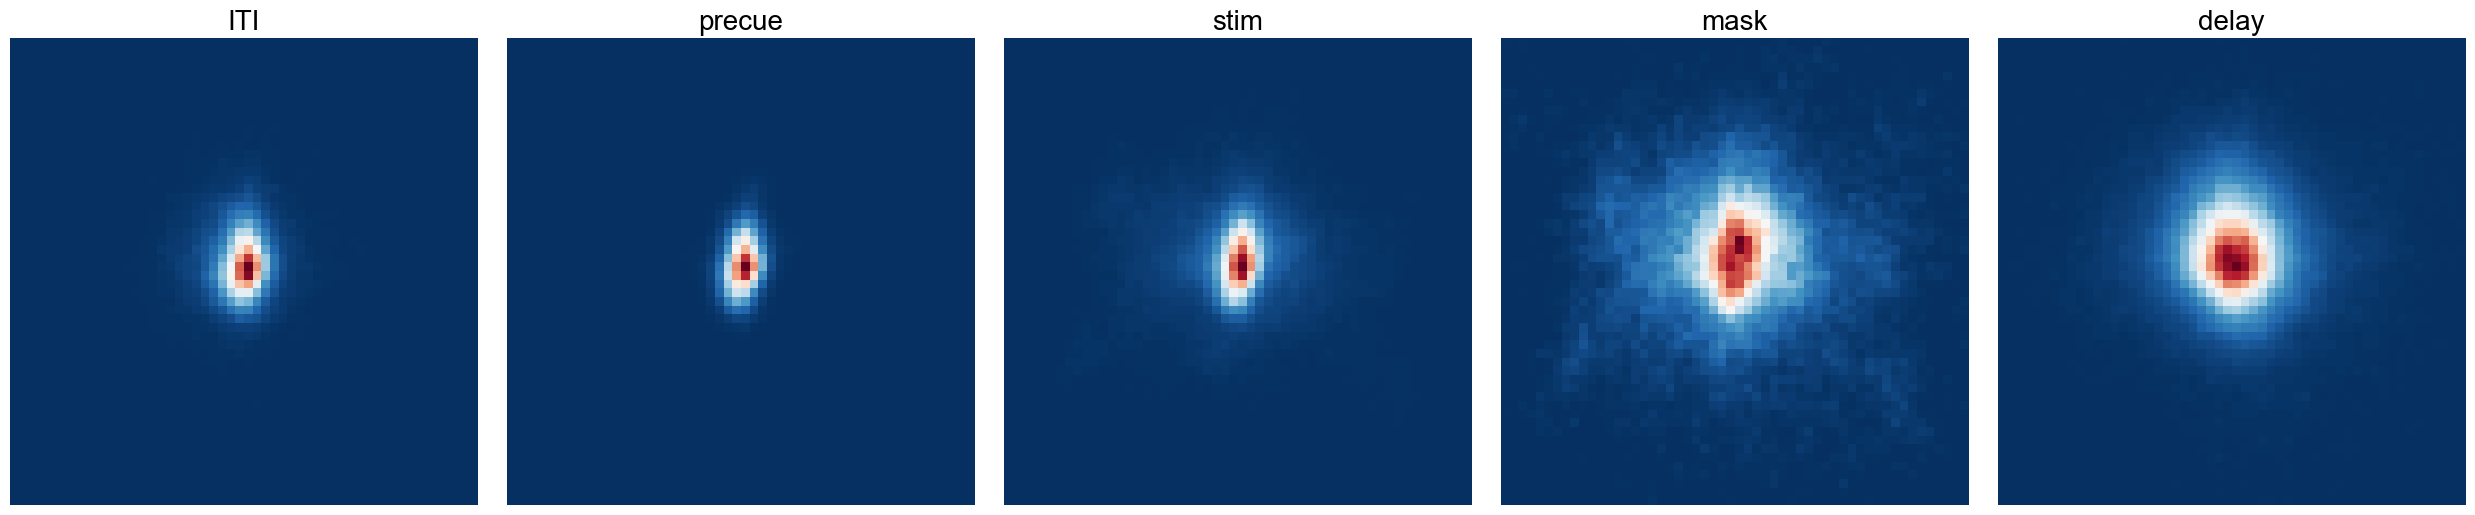

In [22]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for ax, thisHeatmap, (tStart, tEnd, title) in zip(axes, heatmaps_avg,epochs):
    plot_heatmap(ax, thisHeatmap, title)
    ax.set_title(f"{title}", fontsize=20)
plt.tight_layout()



(4.0, 12.0)

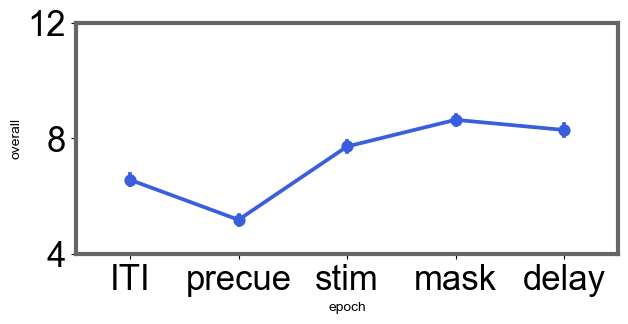

In [65]:
fig,ax = plt.subplots(figsize = (7, 3))
sns.pointplot(data = df_all,
              x = 'epoch', y = 'overall',
              color='#395fdc')#'#395fdc')

ax.tick_params(axis='x', which='major', labelsize=25)
ax.tick_params(axis='y', which='major', labelsize=25)
style_spines(ax)

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(4))
plt.ylim(4,12)

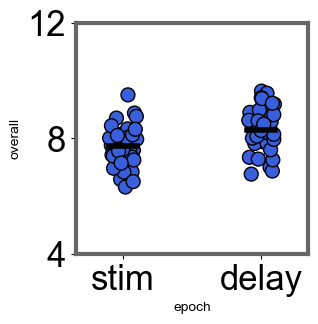

In [24]:
fs(3,3)

fig, ax = plt.subplots(ncols=1, sharex=True, sharey=False)

epoch_order = ['stim', 'delay']


plot_data = df_all[df_all.epoch.isin(epoch_order)]

sns.stripplot(data=plot_data,
              x='epoch', y='overall',
              order=epoch_order, 
              palette=['#395fdc'], jitter=True, alpha=1, size=10,
              linewidth=1, edgecolor='black', zorder=1,
              ax=ax)



# match stripplot's default dodge spacing for 2 hue levels (width=0.8)
dodge_spacing = 0.8 
half_width = 0.1  # length of each mean line

for x_center, epoch in enumerate(epoch_order):
    mean_val = plot_data.loc[
        (plot_data.epoch == epoch), 'overall'
    ].mean()
    ax.plot([x_center - half_width, x_center + half_width],
            [mean_val, mean_val],
            color='black', linewidth=4, zorder=5)

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(4))
ax.tick_params(axis='y', which='major', labelsize=25)
ax.tick_params(axis='x', which='major', labelsize=25)

style_spines(ax)


plt.ylim(4,12)
ax.margins(x=0.2)


In [66]:
def compare_stim_delay(task_df, t_test_verbose = True, **kwargs):
    
    stim = task_df.loc[task_df.epoch == 'stim', 'overall']
    delay = task_df.loc[task_df.epoch == 'delay', 'overall']

    t_result = stats.ttest_rel(stim, delay, nan_policy='omit')
    d = round(cohenD(stim, delay), 2)

    if t_test_verbose:
        print(f"t = {t_result.statistic:.2f}, p = {t_result.pvalue:.4f}, d = {d}")

    return None


In [67]:
compare_stim_delay(df_all,subject = 'participant',
                                    dv = 'overall',
                                    within = ['epoch'])

t = -5.36, p = 0.0000, d = -0.82


### vis vs ver

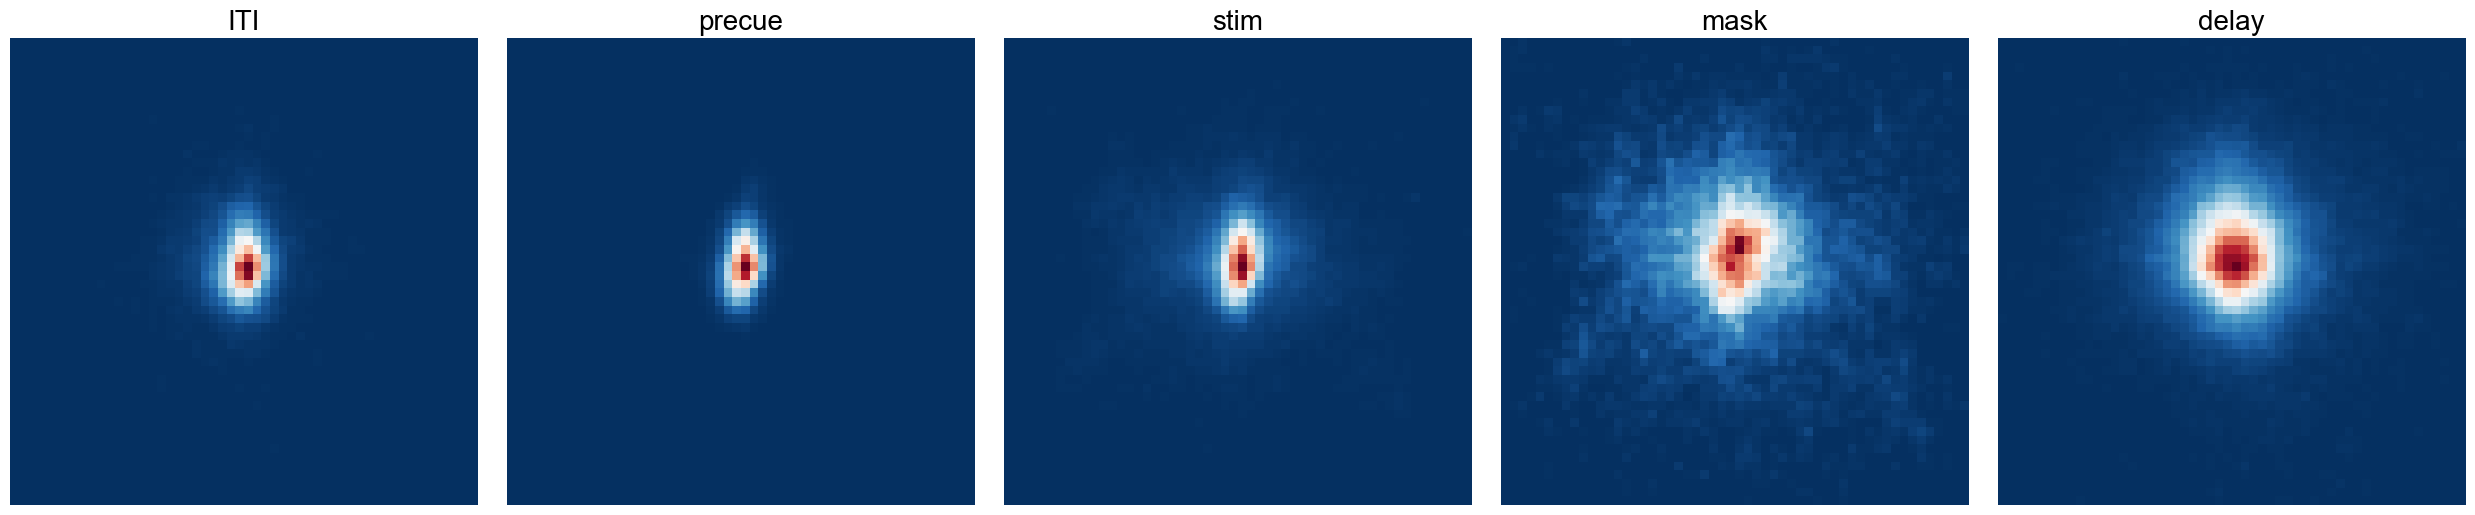

In [70]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for ax, thisHeatmap, (tStart, tEnd, title) in zip(axes, heatmaps_visual_avg,epochs):
    plot_heatmap(ax, thisHeatmap, title)
    ax.set_title(f"{title}", fontsize=20) # Hx={horiz:.2f}  Hy={vert:.2f}
plt.tight_layout()



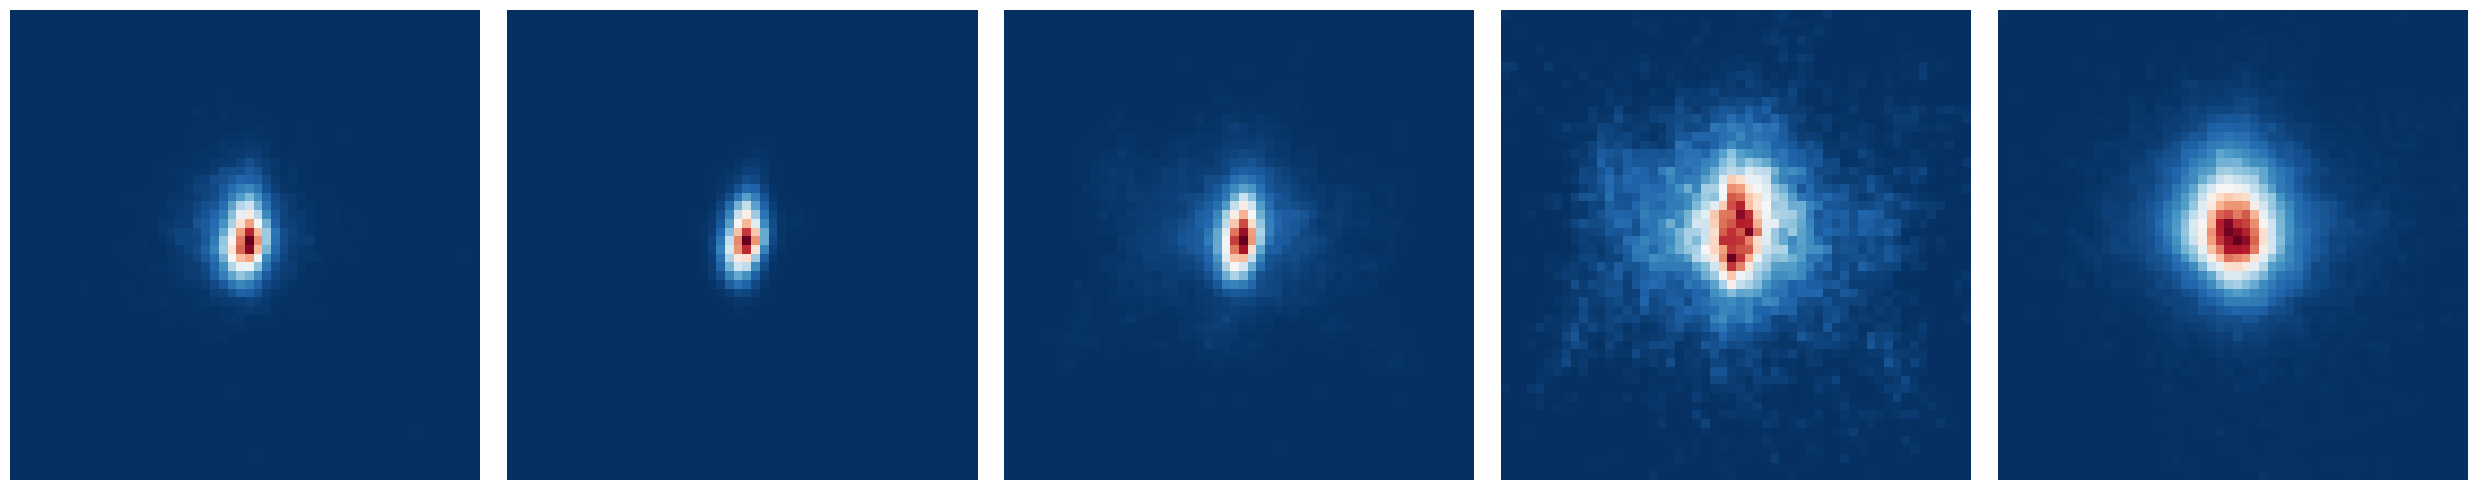

In [71]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, thisHeatmap, (tStart, tEnd, title) in zip(axes, heatmaps_verbal_avg,epochs):
    plot_heatmap(ax, thisHeatmap, title)
    ax.set_title(f"", fontsize=20) # Hx={horiz:.2f}  Hy={vert:.2f}

plt.tight_layout()

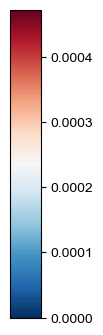

In [61]:
fig_cb, ax_cb = plt.subplots(figsize=(0.4, 4))
vmin = 0
vmax = max(heatmaps_avg.max(),heatmaps_visual_avg.max(), heatmaps_verbal_avg.max())
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
fig_cb.colorbar(sm, cax=ax_cb, orientation='vertical')

plt.tight_layout()

In [62]:
df_visual['trlType'] = 'visual'
df_verbal['trlType'] = 'verbal'
all_precue_entropy = pd.concat([df_visual,df_verbal],axis = 0)

(4.0, 12.0)

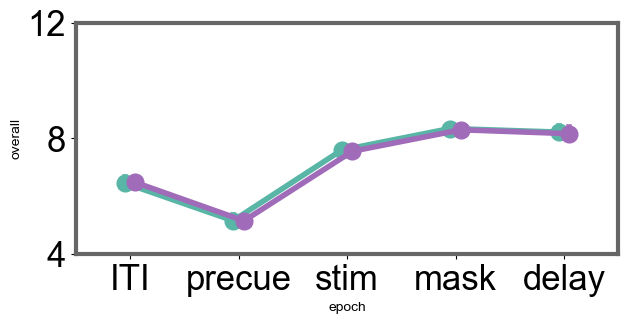

In [63]:


fig,ax = plt.subplots(figsize = (7,3))
sns.pointplot(data = all_precue_entropy,
              x = 'epoch', y = 'overall',
              hue = 'trlType', hue_order= ['visual','verbal'], 
              palette=['#59b6a6','#a06bb9'],
              linewidth = 4, errwidth = 4,dodge = 0.1)


ax.tick_params(axis='x', which='major', labelsize=25)
ax.tick_params(axis='y', which='major', labelsize=25)
style_spines(ax)
ax.get_legend().remove()

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(4))
plt.ylim(4,12)

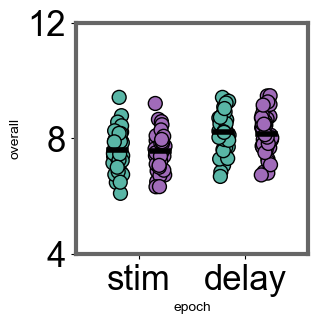

In [43]:
fs(3,3)

fig, ax = plt.subplots(ncols=1, sharex=True, sharey=False)

epoch_order = ['stim', 'delay']
hue_order = ['visual', 'verbal']
palette = ['#59b6a6', '#a06bb9']

plot_data = all_precue_entropy[all_precue_entropy.epoch.isin(epoch_order)]

sns.stripplot(data=plot_data,
              x='epoch', y='overall',
              order=epoch_order,
              hue='trlType', hue_order=hue_order,
              palette=palette,
              dodge=0.1, jitter=True, alpha=1, size=10,
              linewidth=1, edgecolor='black', zorder=1,
              ax=ax)

# match stripplot's default dodge spacing for 2 hue levels (width=0.8)
dodge_spacing = 0.8 / len(hue_order)
half_width = 0.08  # length of each mean line

for i, epoch in enumerate(epoch_order):
    for j, trl in enumerate(hue_order):
        x_center = i + (j - (len(hue_order) - 1) / 2) * dodge_spacing
        mean_val = plot_data.loc[
            (plot_data.epoch == epoch) & (plot_data.trlType == trl), 'overall'
        ].mean()
        ax.plot([x_center - half_width, x_center + half_width],
                [mean_val, mean_val],
                color='black', linewidth=4, zorder=5)

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(4))
ax.tick_params(axis='y', which='major', labelsize=25)
ax.tick_params(axis='x', which='major', labelsize=25)

ax.get_legend().remove()
style_spines(ax)


plt.ylim(4,12)
ax.margins(x=0.2)


In [44]:
results = stats.ttest_rel(
    all_precue_entropy[(all_precue_entropy.epoch == 'stim') & 
                         (all_precue_entropy.trlType == 'visual')]['overall'],
    all_precue_entropy[(all_precue_entropy.epoch == 'stim') &
                         (all_precue_entropy.trlType == 'verbal')]['overall'],
    nan_policy='omit'
)
print(f"t = {results.statistic:.2f}, p = {results.pvalue:.4f}")

t = 1.66, p = 0.1040


In [45]:
results = stats.ttest_rel(
    all_precue_entropy[(all_precue_entropy.epoch == 'delay') & 
                         (all_precue_entropy.trlType == 'visual')]['overall'],
    all_precue_entropy[(all_precue_entropy.epoch == 'delay') &
                         (all_precue_entropy.trlType == 'verbal')]['overall'],
    nan_policy='omit'
)
print(f"t = {results.statistic:.2f}, p = {results.pvalue:.4f}")

t = 1.82, p = 0.0755


## retrocue

In [46]:
# --- load retrocue gaze data ---
gaze_clean_retrocue = pd.read_csv(RETROCUE_GAZE_PATH)

epochs_retrocue = [
    (0,  500, 'ITI'),
    (500,  1500, 'stim'),
    (1500, 2000, 'mask'),
    (2000, 2500, 'blank'),
    (2500, 3000, 'retrocue'),
    (3000, 6000, 'delay'),
]

gaze_clean_retrocue = gaze_clean_retrocue.merge(
    psyFull[['TRIALID', 'trlType', 'participant']],
    how='left', on='TRIALID'
)

# --- per-subject heatmaps + entropy ---
gaze_visual_retrocue = gaze_clean_retrocue[gaze_clean_retrocue.trlType == 'visual']
gaze_verbal_retrocue = gaze_clean_retrocue[gaze_clean_retrocue.trlType == 'verbal']

all_participants_retrocue = gaze_clean_retrocue.participant.unique()  # fixed: was gaze_visual-only before

all_participants_heatmaps_visual_retrocue = []
all_participants_heatmaps_verbal_retrocue = []
all_participants_heatmaps_retrocue = []

rows_visual_retrocue = []
rows_verbal_retrocue = []
rows_all_retrocue = []

for subject in all_participants_retrocue:
    print(subject)

    this_subject = gaze_clean_retrocue[gaze_clean_retrocue.participant == subject]
    this_subject_visual = gaze_visual_retrocue[gaze_visual_retrocue.participant == subject]
    this_subject_verbal = gaze_verbal_retrocue[gaze_verbal_retrocue.participant == subject]

    all_heatmaps_visual = []
    all_heatmaps_verbal = []
    all_heatmaps = []

    for tStart, tEnd, title in epochs_retrocue:
        heatmap_visual = get_gaze_heatmap(this_subject_visual, tStart, tEnd)
        heatmap_verbal = get_gaze_heatmap(this_subject_verbal, tStart, tEnd)
        heatmap = get_gaze_heatmap(this_subject, tStart, tEnd)

        all_heatmaps_visual.append(heatmap_visual)
        all_heatmaps_verbal.append(heatmap_verbal)
        all_heatmaps.append(heatmap)

        rows_visual_retrocue.append({'participant': subject, 'epoch': title,
                                      'overall': get_gaze_entropy(heatmap_visual)})
        rows_verbal_retrocue.append({'participant': subject, 'epoch': title,
                                      'overall': get_gaze_entropy(heatmap_verbal)})
        rows_all_retrocue.append({'participant': subject, 'epoch': title,
                                   'overall': get_gaze_entropy(heatmap)})

    all_participants_heatmaps_visual_retrocue.append(np.array(all_heatmaps_visual))
    all_participants_heatmaps_verbal_retrocue.append(np.array(all_heatmaps_verbal))
    all_participants_heatmaps_retrocue.append(np.array(all_heatmaps))

df_visual_retrocue = pd.DataFrame(rows_visual_retrocue)
df_verbal_retrocue = pd.DataFrame(rows_verbal_retrocue)
df_all_retrocue = pd.DataFrame(rows_all_retrocue)


112430.0
360.0
362.0
363.0
364.0
365.0
366.0
367.0
368.0
369.0
370.0
371.0
372.0
373.0
374.0
375.0
376.0
377.0
378.0
379.0
380.0
381.0
382.0
383.0
384.0
385.0
386.0
387.0
388.0
389.0
390.0
391.0
392.0
393.0
394.0
395.0
396.0
397.0
398.0
399.0
400.0


### agg

In [73]:
# --- averaged heatmaps ---
heatmaps_avg_retrocue = np.array(all_participants_heatmaps_retrocue).mean(axis=0)
heatmaps_visual_avg_retrocue = np.array(all_participants_heatmaps_visual_retrocue).mean(axis=0)
heatmaps_verbal_avg_retrocue = np.array(all_participants_heatmaps_verbal_retrocue).mean(axis=0)


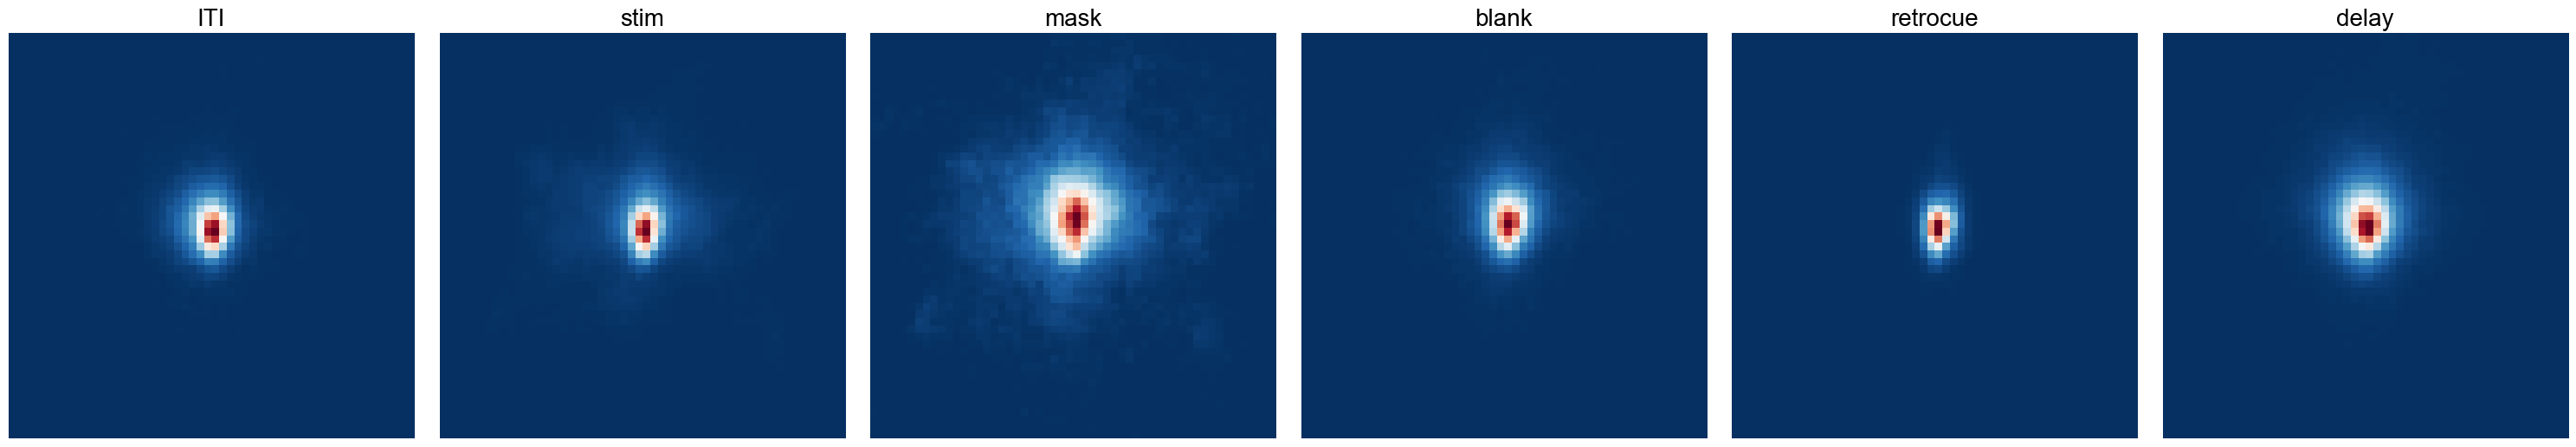

In [74]:

# --- agg heatmaps (6 epochs) ---
fig, axes = plt.subplots(1, len(epochs_retrocue), figsize=(5*len(epochs_retrocue), 5))
for ax, thisHeatmap, (tStart, tEnd, title) in zip(axes, heatmaps_avg_retrocue, epochs_retrocue):
    plot_heatmap(ax, thisHeatmap, title)
    ax.set_title(f"{title}", fontsize=20)
plt.tight_layout()


(4.0, 12.0)

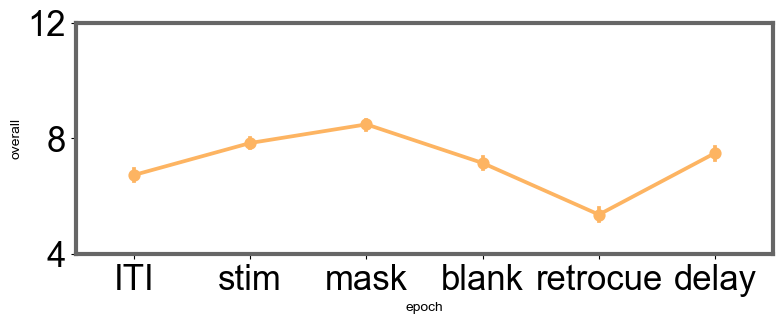

In [75]:
# --- overall entropy across epochs ---
fig, ax = plt.subplots(figsize=(9, 3))
sns.pointplot(data=df_all_retrocue,
              x='epoch', y='overall',
              order=[e[2] for e in epochs_retrocue],
              color='#fdb462')

ax.tick_params(axis='x', which='major', labelsize=25)
ax.tick_params(axis='y', which='major', labelsize=25)
style_spines(ax)

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(4))
plt.ylim(4, 12)


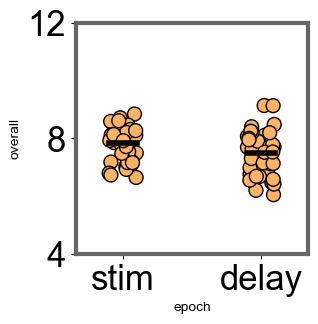

In [76]:
fs(3,3)

fig, ax = plt.subplots(ncols=1, sharex=True, sharey=False)

epoch_order = ['stim', 'delay']


plot_data = df_all_retrocue[df_all_retrocue.epoch.isin(epoch_order)]

sns.stripplot(data=plot_data,
              x='epoch', y='overall',
              order=epoch_order, 
              palette=['#fdb462'], jitter=True, alpha=1, size=10,
              linewidth=1, edgecolor='black', zorder=1,
              ax=ax)



# match stripplot's default dodge spacing for 2 hue levels (width=0.8)
dodge_spacing = 0.8 
half_width = 0.1  # length of each mean line

for x_center, epoch in enumerate(epoch_order):
    mean_val = plot_data.loc[
        (plot_data.epoch == epoch), 'overall'
    ].mean()
    ax.plot([x_center - half_width, x_center + half_width],
            [mean_val, mean_val],
            color='black', linewidth=4, zorder=5)

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(4))
ax.tick_params(axis='y', which='major', labelsize=25)
ax.tick_params(axis='x', which='major', labelsize=25)

style_spines(ax)


plt.ylim(4,12)
ax.margins(x=0.2)


In [77]:
compare_stim_delay(df_all_retrocue,subject = 'participant',
                                    dv = 'overall',
                                    within = ['epoch'])

t = 3.18, p = 0.0029, d = 0.51


### vis vs ver

In [83]:
heatmaps_visual_avg_retrocue.shape

(6, 54, 54)

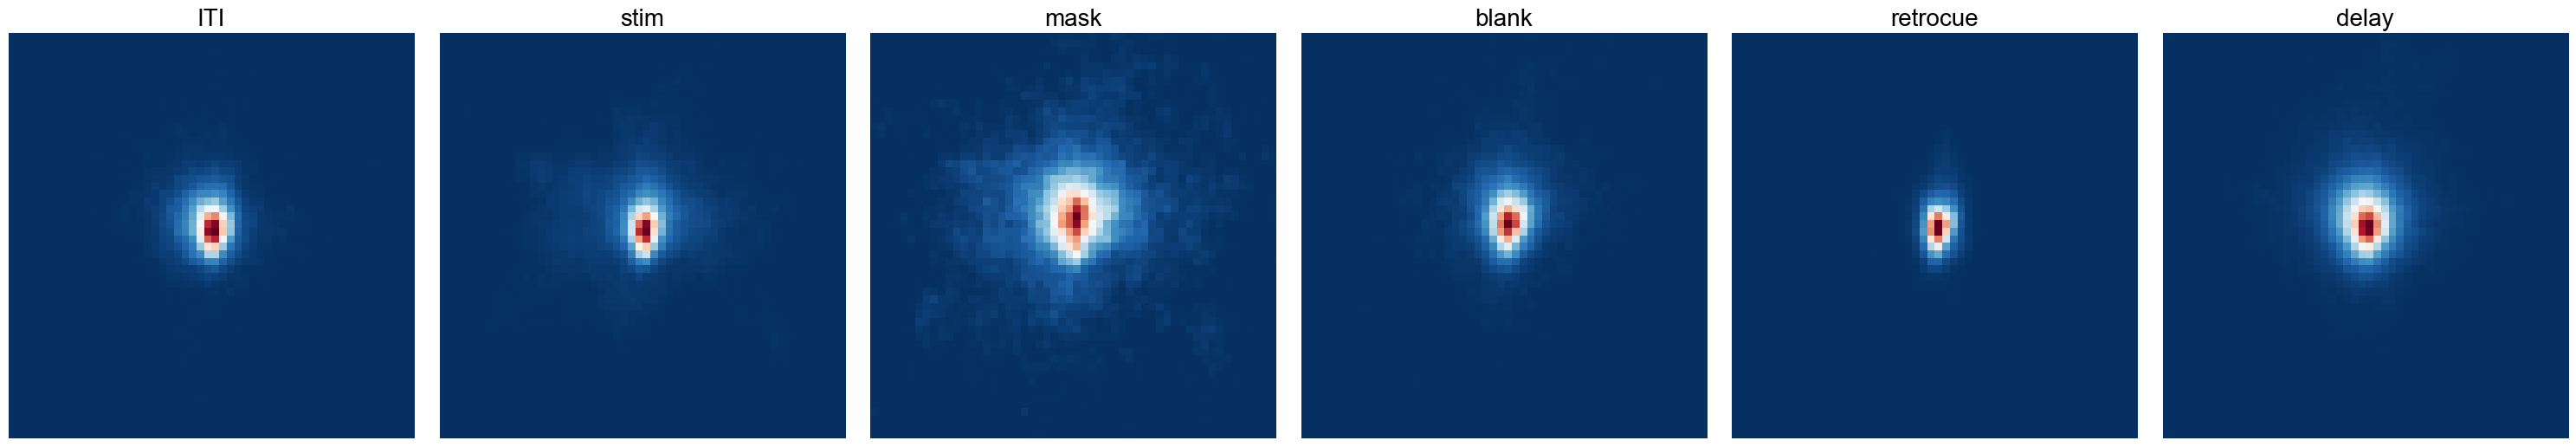

In [85]:
fig, axes = plt.subplots(1, len(epochs_retrocue), figsize=(5*len(epochs_retrocue), 5))

for ax, thisHeatmap, (tStart, tEnd, title) in zip(axes, heatmaps_visual_avg_retrocue,epochs_retrocue):
    plot_heatmap(ax, thisHeatmap, title)
    ax.set_title(f"{title}", fontsize=20) # Hx={horiz:.2f}  Hy={vert:.2f}
plt.tight_layout()



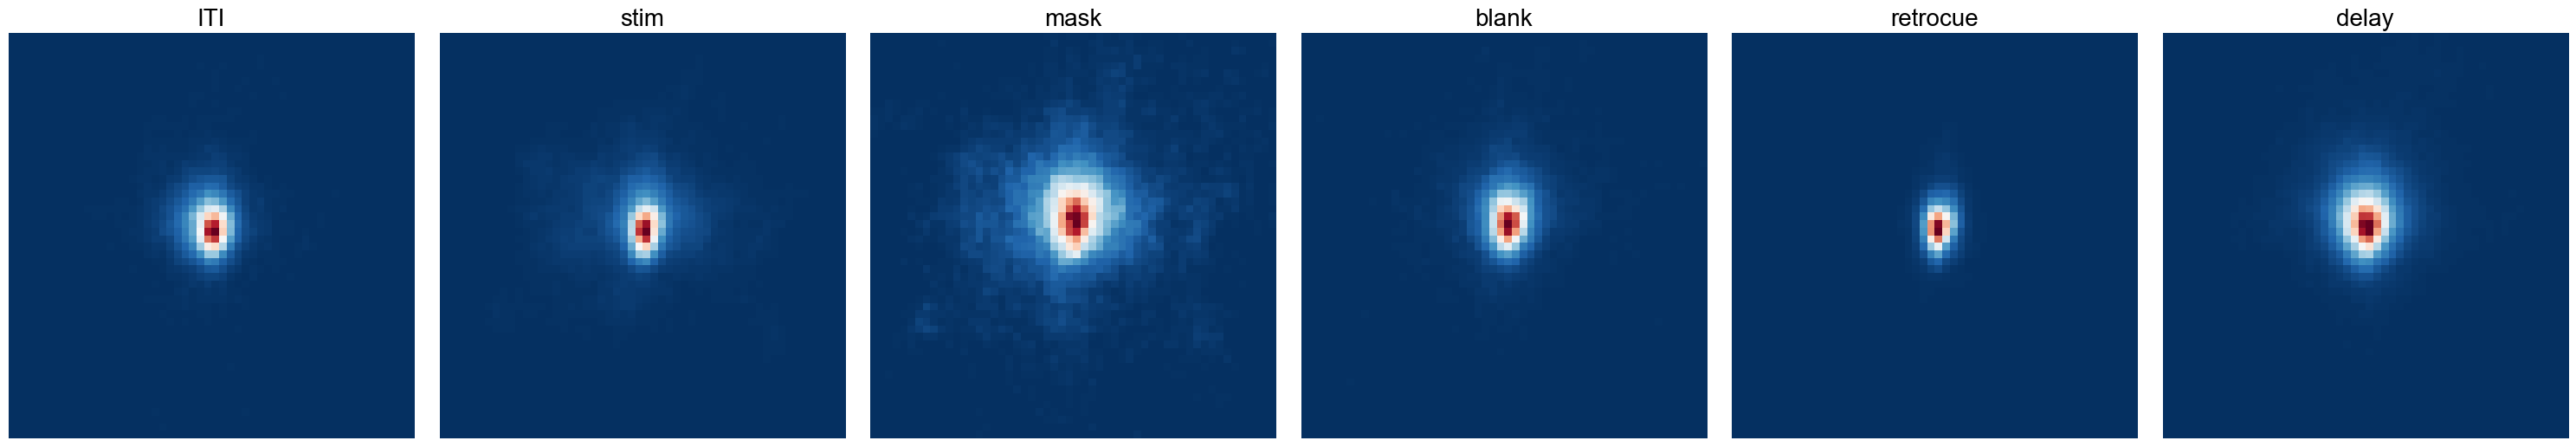

In [86]:
fig, axes = plt.subplots(1, len(epochs_retrocue), figsize=(5*len(epochs_retrocue), 5))

for ax, thisHeatmap, (tStart, tEnd, title) in zip(axes, heatmaps_verbal_avg_retrocue,epochs_retrocue):
    plot_heatmap(ax, thisHeatmap, title)
    ax.set_title(f"{title}", fontsize=20) # Hx={horiz:.2f}  Hy={vert:.2f}
plt.tight_layout()



(4.0, 12.0)

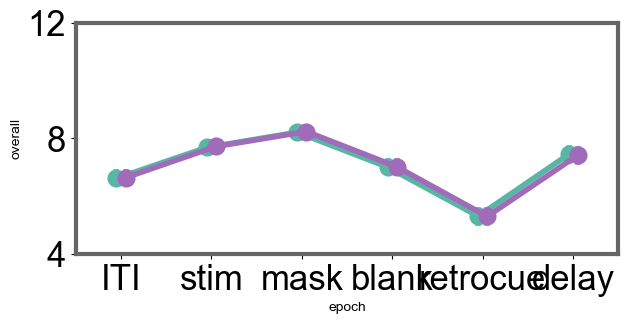

In [78]:
# --- combined df for vis-vs-ver stats/plots ---
df_visual_retrocue['trlType'] = 'visual'
df_verbal_retrocue['trlType'] = 'verbal'
all_retrocue_entropy = pd.concat([df_visual_retrocue, df_verbal_retrocue], axis=0)

fig, ax = plt.subplots(figsize=(7, 3))
sns.pointplot(data=all_retrocue_entropy,
              x='epoch', y='overall',
              order=[e[2] for e in epochs_retrocue],
              hue='trlType', hue_order=['visual', 'verbal'],
              palette=['#59b6a6', '#a06bb9'],
              linewidth=4, errwidth=4, dodge=0.1)

ax.tick_params(axis='x', which='major', labelsize=25)
ax.tick_params(axis='y', which='major', labelsize=25)
style_spines(ax)
ax.get_legend().remove()

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(4))
plt.ylim(4, 12)


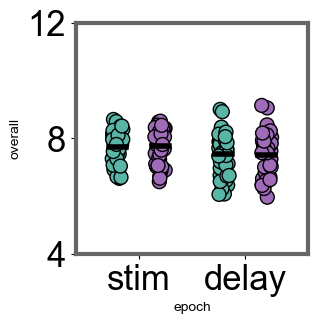

In [79]:
# --- stripplot: stim / retrocue / delay ---
fig, ax = plt.subplots(ncols=1, sharex=True, sharey=False,figsize = (3,3))

epoch_order = ['stim', 'delay']
hue_order = ['visual', 'verbal']
palette = ['#59b6a6', '#a06bb9']

plot_data = all_retrocue_entropy[all_retrocue_entropy.epoch.isin(epoch_order)]

sns.stripplot(data=plot_data,
              x='epoch', y='overall',
              order=epoch_order,
              hue='trlType', hue_order=hue_order,
              palette=palette,
              dodge=0.1, jitter=True, alpha=1, size=10,
              linewidth=1, edgecolor='black', zorder=1,
              ax=ax)

dodge_spacing = 0.8 / len(hue_order)
half_width = 0.08

for i, epoch in enumerate(epoch_order):
    for j, trl in enumerate(hue_order):
        x_center = i + (j - (len(hue_order) - 1) / 2) * dodge_spacing
        mean_val = plot_data.loc[
            (plot_data.epoch == epoch) & (plot_data.trlType == trl), 'overall'
        ].mean()
        ax.plot([x_center - half_width, x_center + half_width],
                [mean_val, mean_val],
                color='black', linewidth=4, zorder=5)

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(4))
ax.tick_params(axis='y', which='major', labelsize=25)
ax.tick_params(axis='x', which='major', labelsize=25)

ax.get_legend().remove()
style_spines(ax)

plt.ylim(4, 12)
ax.margins(x=0.2)


In [80]:
# --- paired t-tests: visual vs verbal, per epoch ---
for ep in ['stim', 'delay']:
    result = stats.ttest_rel(
        all_retrocue_entropy[(all_retrocue_entropy.epoch == ep) &
                              (all_retrocue_entropy.trlType == 'visual')]['overall'],
        all_retrocue_entropy[(all_retrocue_entropy.epoch == ep) &
                              (all_retrocue_entropy.trlType == 'verbal')]['overall'],
        nan_policy='omit'
    )
    print(f"t = {result.statistic:.2f}, p = {result.pvalue:.4f}")


t = -1.87, p = 0.0693
t = 1.25, p = 0.2203
